In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar

import xarray as xr

FAOSTAT food balance sheets describe food supply patterns from countries and regions as a function of time and food commodity.
Latest FAOSTAT data can be downloaded from the FAO website:

- https://www.fao.org/faostat/en/#data/FBS for data published since 2010 utilizing new methodology

The array created here stores data from the new methodology from 2010 on.
To get the datasets, select the 'All Data Normalized' option on the right hand side panel of the sites to get a compressed folder which include the file named in the cell below.
In this notebook the values are extracted and stored in an easy to manage xarray DataSet which is then read by the AgriFoodPy package when the FAOSTAT dataset is imported.

```python
from agrifoodpy.food.food_supply import FAOSTAT_FBS
```

Additionally, item groups and origins are obtained from the same url by clicking on the "Definitions and standards" button on the right.
A pop-up will appear. When clicking on "Item group", all items and their corresponding groupings will be displayed in a table which can be downloaded as a CSV file which we will
use to assign label coordinates with additional data to each item. The generated file will have the following name format, which will depend on the date it is downloaded:

```FAOSTAT_data_DD_MM_YYYY.csv```


## Food balance sheets

The dimensions of the array include:

- **Year**
- **Region code**
- Region name
- **Item code**
- Item name
- Item origin
- Item group

The main named dimensions shown in bold are used to index the array, while the rest are used for labelling. These can be useful when grouping into broader categories (Animal vs vegetal origin, or food groups)

The Dataset contains the following element DataArrays:

- Stock Variation
- Losses
- Processing
- Food
- Other uses (non-food)
- Residuals
- Tourist consumption
- Domestic supply quantity
- Production
- Feed
- Seed
- Import Quantity
- Export Quantity

## Nutrient data

Additionally, basic nutrient data is derived from the total consumption values by weight and the reported intakes in the following elements:

- Food supply (kcal/capita/day)
- Protein supply quantity (g/capita/day)
- Fat supply quantity (g/capita/day)

Here we generate an xarray Dataset of nutrients per weight as a function of year and region. This is stored in a separate file which can be imported in agrifoopy as

``` python
from agrifoopy.food.food_supply import Nutrients_FAOSTAT_FBS
```

## Population data

Population data is also contained in the input CSV files. A DataArray is generated here and stored as an alternative to UN population data.
Population estimations from 1961 to 2020 are provided for each year and region defined in the FAOSTAT database.
The array created here can be imported in agrifoodpy as

``` python
from agrifoopy.population.population import FAOSTAT_FBS
```

In [2]:
# (2010-)
fbs_csv = 'FoodBalanceSheets_E_All_Data_(Normalized).csv'

In [3]:
fbs = pd.read_csv(fbs_csv, encoding = 'latin1') # 2010 - present

fbs = fbs[['Area Code', 'Area', 'Element', 'Element Code', 'Item', 'Item Code', 'Year', 'Unit', 'Value']]
years = np.unique(fbs['Year'])

In [4]:
years

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023])

In [5]:
# nuts_old_code = fbs_1[fbs_1['Item'] == 'Groundnuts (Shelled Eq)'].iloc[0]['Item Code']
# rice_old_code = fbs_1[fbs_1['Item'] == 'Rice (Milled Equivalent)'].iloc[0]['Item Code']

# nuts_new_code = fbs[fbs['Item'] == 'Groundnuts'].iloc[0]['Item Code']
# rice_new_code = fbs[fbs['Item'] == 'Rice and products'].iloc[0]['Item Code']

# milk_codes = pd.unique(fbs[fbs['Item'] == 'Milk - Excluding Butter']['Item Code'])
# eggs_codes = pd.unique(fbs[fbs['Item'] == 'Eggs']['Item Code'])


# print(f'Groundnuts: old code = {nuts_old_code}, new code = {nuts_new_code}')
# print(f'Rice and products: old code = {rice_old_code}, new code = {rice_new_code}')

# print(f'Milk: old code = {milk_codes[0]}, new code = {milk_codes[1]}')
# print(f'Eggs: old code = {eggs_codes[0]}, new code = {eggs_codes[1]}')

# print('Milk codes:', milk_codes)
# print('Eggs codes:', eggs_codes)

In [6]:
# We'll rename some of the items due to changes in naming convention
# fbs.loc[fbs['Item Code'] == rice_old_code, 'Item'] = "Rice and products"
# fbs.loc[fbs['Item Code'] == rice_old_code, 'Item Code'] = rice_new_code

# fbs.loc[fbs['Item Code'] == nuts_old_code, 'Item'] = "Groundnuts"
# fbs.loc[fbs['Item Code'] == nuts_old_code, 'Item Code'] = nuts_new_code

# # Also, will remove the 'Miscellaneous' item as it has incomplete data
# fbs.drop(fbs.loc[fbs['Item'] == 'Grand Total'].index, inplace=True)

# # Finally, drop all duplicates of Eggs and Milk, store population data for later and drop it

population = fbs.loc[(fbs['Item Code'] == 2501) & (fbs["Element"] == 'Total Population - Both sexes')]
fbs.drop(fbs.loc[fbs['Item Code'].isin([2501])].index, inplace=True)

fbs

,Area Code,Area,Element,Element Code,Item,Item Code,Year,Unit,Value
107,2,Afghanistan,Food supply (kcal/capita/day),664,Grand Total,2901,2010,kcal/cap/d,2200.21
128,2,Afghanistan,Food supply (kcal/capita/day),664,Grand Total,2901,2011,kcal/cap/d,2171.86
134,3,Albania,Food supply (kcal/capita/day),664,Grand Total,2901,2010,kcal/cap/d,3237.43
137,13,Bahrain,Food supply (kcal/capita/day),664,Grand Total,2901,2019,kcal/cap/d,3489.08
138,2,Afghanistan,Food supply (kcal/capita/day),664,Grand Total,2901,2012,kcal/cap/d,2165.88
...,...,...,...,...,...,...,...,...,...
4820492,5000,World,Fat supply quantity (t),681,Miscellaneous,2899,2019,t,74754.23
4820493,5000,World,Fat supply quantity (t),681,Miscellaneous,2899,2020,t,75900.44
4820494,5000,World,Fat supply quantity (t),681,Miscellaneous,2899,2021,t,74636.45
4820495,5000,World,Fat supply quantity (t),681,Miscellaneous,2899,2022,t,78065.29


# Food balance sheets

## Region and Item codes

In [7]:
area_names = pd.unique(fbs['Area'])
area_codes = pd.unique(fbs['Area Code'])

sorting = np.argsort(area_codes)
area_codes = area_codes[sorting]
area_names = area_names[sorting]

for name, code in zip(area_names, area_codes):
    print(code, name)

1 Armenia
2 Afghanistan
3 Albania
4 Algeria
7 Angola
8 Antigua and Barbuda
9 Argentina
10 Australia
11 Austria
12 Bahamas
13 Bahrain
14 Barbados
16 Bangladesh
18 Bhutan
19 Bolivia (Plurinational State of)
20 Botswana
21 Brazil
23 Belize
25 Solomon Islands
27 Bulgaria
28 Myanmar
32 Cameroon
33 Canada
35 Cabo Verde
38 Sri Lanka
40 Chile
41 China, mainland
44 Colombia
45 Comoros
46 Congo
48 Costa Rica
49 Cuba
50 Cyprus
52 Azerbaijan
54 Denmark
56 Dominican Republic
57 Belarus
58 Ecuador
59 Egypt
60 El Salvador
63 Estonia
66 Fiji
67 Finland
68 France
70 French Polynesia
72 Djibouti
73 Georgia
74 Gabon
75 Gambia
79 Germany
80 Bosnia and Herzegovina
81 Ghana
83 Kiribati
84 Greece
86 Grenada
89 Guatemala
90 Guinea
91 Guyana
93 Haiti
95 Honduras
96 China, Hong Kong SAR
97 Hungary
98 Croatia
99 Iceland
100 India
101 Indonesia
102 Iran (Islamic Republic of)
103 Iraq
104 Ireland
105 Israel
106 Italy
107 CÃ´te d'Ivoire
108 Kazakhstan
109 Jamaica
112 Jordan
113 Kyrgyzstan
114 Kenya
115 Cambodia
116

In [8]:
item_codes = pd.unique(fbs['Item Code'])
item_codes = item_codes[np.argsort(item_codes)]

# Some names are used for multiple hierarchies.
# We use item codes to get unique names
item_names = [fbs[fbs['Item Code'] == code]['Item'].iloc[0] for code in item_codes]

for i, (code, name) in enumerate(zip(item_codes, item_names)):
    print(i, code, name)

0 2511 Wheat and products
1 2513 Barley and products
2 2514 Maize and products
3 2515 Rye and products
4 2516 Oats
5 2517 Millet and products
6 2518 Sorghum and products
7 2520 Cereals, other
8 2531 Potatoes and products
9 2532 Cassava and products
10 2533 Sweet potatoes
11 2534 Roots, Other
12 2535 Yams
13 2536 Sugar cane
14 2537 Sugar beet
15 2541 Sugar non-centrifugal
16 2542 Sugar (Raw Equivalent)
17 2543 Sweeteners, Other
18 2546 Beans
19 2547 Peas
20 2549 Pulses, Other and products
21 2551 Nuts and products
22 2552 Groundnuts
23 2555 Soyabeans
24 2557 Sunflower seed
25 2558 Rape and Mustardseed
26 2559 Cottonseed
27 2560 Coconuts - Incl Copra
28 2561 Sesame seed
29 2562 Palm kernels
30 2563 Olives (including preserved)
31 2570 Oilcrops, Other
32 2571 Soyabean Oil
33 2572 Groundnut Oil
34 2573 Sunflowerseed Oil
35 2574 Rape and Mustard Oil
36 2575 Cottonseed Oil
37 2576 Palmkernel Oil
38 2577 Palm Oil
39 2578 Coconut Oil
40 2579 Sesameseed Oil
41 2580 Olive Oil
42 2581 Ricebran Oi

In [9]:
# Read the item code, name and group data and create an array
# with the groups for each entry on item_codes / item_names
groups = pd.read_csv("FAOSTAT_data_8-18-2026.csv")
groups = groups.drop(groups[groups["Item Group"] == "Grand Total"].index)
groups

,Item Group Code,Item Group,Item Code,Item,Factor,CPC Code,HS Code,HS07 Code,HS12 Code
0,2905,Cereals - Excluding Beer,2511,Wheat and products,1,NaN,NaN,NaN,NaN
2,2903,Vegetal Products,2511,Wheat and products,1,NaN,NaN,NaN,NaN
3,2905,Cereals - Excluding Beer,2807,Rice and products,1,NaN,NaN,NaN,NaN
5,2903,Vegetal Products,2807,Rice and products,1,NaN,NaN,NaN,NaN
6,2905,Cereals - Excluding Beer,2513,Barley and products,1,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
286,2961,"Aquatic Products, Other",2775,Aquatic Plants,1,NaN,NaN,NaN,NaN
289,2928,Miscellaneous,2680,Infant food,1,NaN,NaN,NaN,NaN
290,2903,Vegetal Products,2680,Infant food,1,NaN,NaN,NaN,NaN
292,2928,Miscellaneous,2899,Miscellaneous,1,NaN,NaN,NaN,NaN


In [10]:
# Now we obtain a list of item groups and origins aligned witht the item_codes and item_names lists. This will be used to create a new column in the fbs dataframe with the group of each item.

item_groups = []
item_origins = []

# First check the origin of the items
for code, name  in zip(item_codes, item_names):
    
    g = groups["Item Group"][groups["Item Code"] == code]    
    
    if "Vegetal Products" in g.to_numpy():
        item_origins.append("Vegetal Products")
        
    elif "Animal Products" in g.to_numpy():
        item_origins.append("Animal Products")
    
    elif code < 2940:
        item_origins.append("Vegetal Products")

    else:
        item_origins.append("Animal Products")

In [11]:
for code, name, origin in zip(item_codes, item_names, item_origins):
    print(f"{code:<4} {name:<30} {origin}")

2511 Wheat and products             Vegetal Products
2513 Barley and products            Vegetal Products
2514 Maize and products             Vegetal Products
2515 Rye and products               Vegetal Products
2516 Oats                           Vegetal Products
2517 Millet and products            Vegetal Products
2518 Sorghum and products           Vegetal Products
2520 Cereals, other                 Vegetal Products
2531 Potatoes and products          Vegetal Products
2532 Cassava and products           Vegetal Products
2533 Sweet potatoes                 Vegetal Products
2534 Roots, Other                   Vegetal Products
2535 Yams                           Vegetal Products
2536 Sugar cane                     Vegetal Products
2537 Sugar beet                     Vegetal Products
2541 Sugar non-centrifugal          Vegetal Products
2542 Sugar (Raw Equivalent)         Vegetal Products
2543 Sweeteners, Other              Vegetal Products
2546 Beans                          Vegetal Pr

In [12]:
# Remove Vegetal and Animal origins from item list and then repeat with item groups:
      
groups = groups.drop(groups[groups["Item Group"] == "Animal Products"].index)
groups = groups.drop(groups[groups["Item Group"] == "Vegetal Products"].index)

for code, name  in zip(item_codes, item_names):
    
    g = groups["Item Group"][groups["Item Code"] == code].to_numpy()
    
    try:
        item_groups.append(g[0])
        
    except IndexError:
        item_groups.append(name)

In [13]:
print(len(item_codes), " Food items\n")
print("Code, Name, Group, Origin \n")
for name, code, group, origin in zip(item_names, item_codes, item_groups, item_origins):
    print(f"{code:<4} {name:<32} {group:<30} {origin}")

122  Food items

Code, Name, Group, Origin 

2511 Wheat and products               Cereals - Excluding Beer       Vegetal Products
2513 Barley and products              Cereals - Excluding Beer       Vegetal Products
2514 Maize and products               Cereals - Excluding Beer       Vegetal Products
2515 Rye and products                 Cereals - Excluding Beer       Vegetal Products
2516 Oats                             Cereals - Excluding Beer       Vegetal Products
2517 Millet and products              Cereals - Excluding Beer       Vegetal Products
2518 Sorghum and products             Cereals - Excluding Beer       Vegetal Products
2520 Cereals, other                   Cereals - Excluding Beer       Vegetal Products
2531 Potatoes and products            Starchy Roots                  Vegetal Products
2532 Cassava and products             Starchy Roots                  Vegetal Products
2533 Sweet potatoes                   Starchy Roots                  Vegetal Products
2534 Root

## Element codes

In [14]:
# Element codes, units and names. Remove population data
element_codes = pd.unique(fbs['Element Code'])
element_names = pd.unique(fbs['Element'])
element_units= []

for code in element_codes:
    unit = fbs[fbs['Element Code'] == code].iloc[0]['Unit']
    element_units.append(unit)

element_units = np.array(element_units)

# Sort by item code
sorting = np.argsort(element_codes)
element_codes = element_codes[sorting]
element_names = element_names[sorting]
element_units = element_units[sorting]
    
for i, (code, name) in enumerate(zip(element_codes, element_names)):
    print(code, element_units[i], name )

645 kg/cap Food supply quantity (kg/capita/yr)
661 million Kcal Food supply (kcal)
664 kcal/cap/d Food supply (kcal/capita/day)
671 t Protein supply quantity (t)
674 g/cap/d Protein supply quantity (g/capita/day)
681 t Fat supply quantity (t)
684 g/cap/d Fat supply quantity (g/capita/day)
5072 1000 t Stock Variation
5123 1000 t Losses
5131 1000 t Processing
5142 1000 t Food
5154 1000 t Other uses (non-food)
5170 1000 t Residuals
5171 1000 t Tourist consumption
5301 1000 t Domestic supply quantity
5511 1000 t Production
5521 1000 t Feed
5527 1000 t Seed
5611 1000 t Import quantity
5911 1000 t Export quantity


## Filling incomplete data and store into array

Checking for incomplete data shows that several Items are not present in all areas, and some items without certain nutrients are ommited from the data.
We will fix that to have a rectangular array to facilitate usage with xarray. When data is not present, we will fill with zeros.

In [15]:
# We define indexes for each of the dimensions of the data
iy = fbs['Year'] - years[0]

# Some numpy trickery to get the indices for the area, elements and items
ia = np.nonzero(fbs['Area Code'].to_numpy()[:, None] == area_codes)[1]
ie = np.nonzero(fbs['Element Code'].to_numpy()[:, None] == element_codes)[1]
ic = np.nonzero(fbs['Item Code'].to_numpy()[:, None] == item_codes)[1]

# We compute the index in the flattened array
ipos = ia * len(years) * len(element_codes) * len(item_codes) + \
       iy * len(element_codes) * len(item_codes) + \
       ie * len(item_codes) + \
       ic

ipos = ipos.astype(int)

In [16]:
# Create 1d array filled with zeros
fbs_arr = np.zeros(len(area_codes)*len(years)*len(element_codes)*len(item_codes))
fbs_arr[ipos] = fbs['Value']

# Reshape array to desired shape
fbs_arr = fbs_arr.reshape((len(area_codes), len(years), len(element_codes), len(item_codes)))

In [17]:
data = xr.Dataset(
    data_vars = dict(

        stock=(["Region", "Year", "Item"], fbs_arr[:,:,7]),
        losses=(["Region", "Year", "Item"], fbs_arr[:,:,8]),
        processing=(["Region", "Year", "Item"], fbs_arr[:,:,9]),
        food=(["Region", "Year", "Item"], fbs_arr[:,:,10]),
        other=(["Region", "Year", "Item"], fbs_arr[:,:,11]),
        residual=(["Region", "Year", "Item"], fbs_arr[:,:,12]),
        tourist=(["Region", "Year", "Item"], fbs_arr[:,:,13]),
        domestic=(["Region", "Year", "Item"], fbs_arr[:,:,14]),
        production=(["Region", "Year", "Item"], fbs_arr[:,:,15]),
        feed=(["Region", "Year", "Item"], fbs_arr[:,:,16]),
        seed=(["Region", "Year", "Item"], fbs_arr[:,:,17]),
        imports=(["Region", "Year", "Item"], fbs_arr[:,:,18]),
        exports=(["Region", "Year", "Item"], fbs_arr[:,:,19]),
        
    ),
    coords = {
        "Region":("Region", area_codes),
        "Region_name":("Region", area_names),
        "Year":("Year", years),
        "Item":("Item", item_codes),
        "Item_name":("Item", item_names),     
        "Item_group":("Item", item_groups),     
        "Item_origin":("Item", item_origins),        
    }
)

Checking that the arrays are indexed correctly

In [35]:
data.sel(Region=5707, Year=2019, Item=2918)

<xarray.Dataset> Size: 420B
Dimensions:      ()
Coordinates:
    Region       int64 8B 5707
    Region_name  object 8B 'European Union (27)'
    Year         int64 8B 2019
    Item         int64 8B 2918
    Item_name    <U31 124B 'Vegetables'
    Item_group   <U24 96B 'Vegetables'
    Item_origin  <U16 64B 'Vegetal Products'
Data variables: (12/13)
    stock        float64 8B 1.751e+03
    losses       float64 8B 6.323e+03
    processing   float64 8B 629.0
    food         float64 8B 6.294e+04
    other        float64 8B 3.0
    residual     float64 8B -1.358e+03
    ...           ...
    domestic     float64 8B 6.965e+04
    production   float64 8B 6.05e+04
    feed         float64 8B 1.087e+03
    seed         float64 8B 0.0
    imports      float64 8B 4.982e+04
    exports      float64 8B 3.891e+04

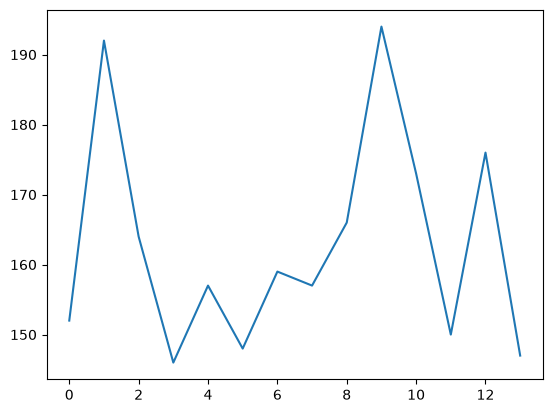

In [19]:
plt.plot(data.exports.sel(Item=2731, Region=229))

In [20]:
print(fbs[(fbs["Area Code"]==229) &
          (fbs["Year"]==2019) &
          (fbs["Element Code"]==5142) &
          (fbs["Item Code"]== 2511)]['Value'].values)

print(data["food"].sel(Region=229, 
               Year=2019, 
               Item=2511).values)

[7898.]
7898.0


In [21]:
encoding = {}
for data_var in data.data_vars:
    encoding[data_var] = {"dtype":"float32", "zlib": True, "complevel": 5}
    
data.to_netcdf("../data/FAOSTAT_FBS.nc", encoding=encoding)

# Population

In [22]:
population

,Area Code,Area,Element,Element Code,Item,Item Code,Year,Unit,Value
0,2,Afghanistan,Total Population - Both sexes,511,Population,2501,2010,1000 No,28284.09
1,3,Albania,Total Population - Both sexes,511,Population,2501,2010,1000 No,2928.72
2,2,Afghanistan,Total Population - Both sexes,511,Population,2501,2011,1000 No,29347.71
3,3,Albania,Total Population - Both sexes,511,Population,2501,2011,1000 No,2911.50
4,2,Afghanistan,Total Population - Both sexes,511,Population,2501,2012,1000 No,30560.03
...,...,...,...,...,...,...,...,...,...
25115,5803,Small Island Developing States (SIDS),Total Population - Both sexes,511,Population,2501,2023,1000 No,62202.30
25117,5815,Low Income Food Deficit Countries (LIFDCs),Total Population - Both sexes,511,Population,2501,2022,1000 No,1035872.19
25330,5815,Low Income Food Deficit Countries (LIFDCs),Total Population - Both sexes,511,Population,2501,2023,1000 No,1062129.50
25334,5817,Net Food Importing Developing Countries (NFIDCs),Total Population - Both sexes,511,Population,2501,2022,1000 No,1777119.85


In [23]:
# We find indexes for each of the dimensions of the data
iy = population['Year'] - years[0]

# Some numpy trickery to get the indices for the area, elements and items
ia = np.nonzero(population['Area Code'].to_numpy()[:, None] == area_codes)[1]

# We compute the index in the flattened array
ipos = ia * len(years) + iy
ipos = ipos.astype(int)

In [24]:
# Create 1d array filled with np.NaN
pop_arr = np.zeros(len(area_codes)*len(years))
pop_arr[ipos] = population['Value']

# Reshape array to desired shape
pop_arr = pop_arr.reshape((len(area_codes), len(years)))

In [25]:
population_data = xr.Dataset(
    
    data_vars = dict(population=(["Region", "Year"], pop_arr*1000)),
    coords = {
        "Region":("Region", area_codes),
        "Region_name":("Region", area_names),
        "Year":("Year", years),
    }
)

population_data

<xarray.Dataset> Size: 27kB
Dimensions:      (Region: 213, Year: 14)
Coordinates:
  * Region       (Region) int64 2kB 1 2 3 4 7 8 ... 5801 5802 5803 5815 5817
    Region_name  (Region) object 2kB 'Armenia' ... 'Net Food Importing Develo...
  * Year         (Year) int64 112B 2010 2011 2012 2013 ... 2020 2021 2022 2023
Data variables:
    population   (Region, Year) float64 24kB 2.931e+06 2.923e+06 ... 1.813e+09

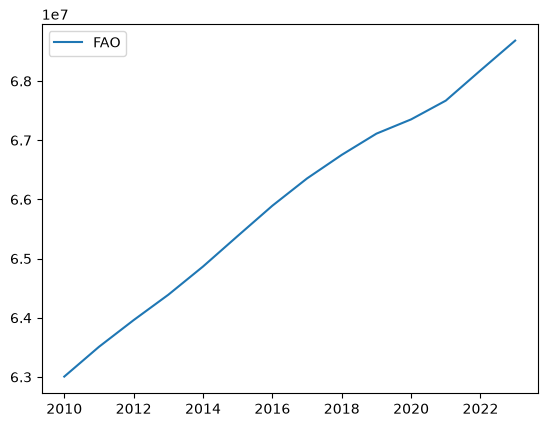

In [26]:
pop_uk_FAO = population_data.population.sel(Region=229)

plt.plot(years, pop_uk_FAO, label="FAO")
plt.legend()

In [27]:
population_encoding = {}
for data_var in population_data.data_vars:
    population_encoding[data_var] = {"dtype":"float32", "zlib": True, "complevel": 5}
    
population_data.to_netcdf("../../population/data/Population_FAOSTAT_FBS.nc", encoding=population_encoding)

# Nutrient data

Lets compute the nutrients per mass of item, by taking the daily per capita intakes and dividing by the daily weight consumed per item

In [28]:
nutrient_data = xr.Dataset(
    data_vars = dict(

        kcal=(["Region", "Year", "Item"], fbs_arr[:,:,2]),
        protein=(["Region", "Year", "Item"], fbs_arr[:,:,4]),
        fat=(["Region", "Year", "Item"], fbs_arr[:,:,6]),
        
    ),
    coords = {
        "Region":("Region", area_codes),
        "Region_name":("Region", area_names),
        "Year":("Year", years),
        "Item":("Item", item_codes),
        "Item_name":("Item", item_names),     
        "Item_group":("Item", item_groups),     
        "Item_origin":("Item", item_origins),        
    }
)
# This is g_nutrient / cap / day
nutrient_data

<xarray.Dataset> Size: 9MB
Dimensions:      (Region: 213, Year: 14, Item: 122)
Coordinates:
  * Region       (Region) int64 2kB 1 2 3 4 7 8 ... 5801 5802 5803 5815 5817
    Region_name  (Region) object 2kB 'Armenia' ... 'Net Food Importing Develo...
  * Year         (Year) int64 112B 2010 2011 2012 2013 ... 2020 2021 2022 2023
  * Item         (Item) int64 976B 2511 2513 2514 2515 ... 2948 2949 2960 2961
    Item_name    (Item) <U31 15kB 'Wheat and products' ... 'Aquatic Products,...
    Item_group   (Item) <U24 12kB 'Cereals - Excluding Beer' ... 'Aquatic Pro...
    Item_origin  (Item) <U16 8kB 'Vegetal Products' ... 'Animal Products'
Data variables:
    kcal         (Region, Year, Item) float64 3MB 952.2 115.2 ... 22.21 0.0
    protein      (Region, Year, Item) float64 3MB 29.87 3.8 1.11 ... 3.21 0.0
    fat          (Region, Year, Item) float64 3MB 4.84 0.66 0.45 ... 1.02 0.0

In [29]:
# (g_nutrient / cap / day) / (g_food / cap / day) = g_nutrient / g_food  

food_day_capita = data["food"]*1e9/population_data["population"]/365.25
nutrients_gram = nutrient_data / food_day_capita
nutrients_gram

<xarray.Dataset> Size: 9MB
Dimensions:      (Region: 213, Year: 14, Item: 122)
Coordinates:
  * Region       (Region) int64 2kB 1 2 3 4 7 8 ... 5801 5802 5803 5815 5817
    Region_name  (Region) object 2kB 'Armenia' ... 'Net Food Importing Develo...
  * Year         (Year) int64 112B 2010 2011 2012 2013 ... 2020 2021 2022 2023
  * Item         (Item) int64 976B 2511 2513 2514 2515 ... 2948 2949 2960 2961
    Item_name    (Item) <U31 15kB 'Wheat and products' ... 'Aquatic Products,...
    Item_group   (Item) <U24 12kB 'Cereals - Excluding Beer' ... 'Aquatic Pro...
    Item_origin  (Item) <U16 8kB 'Vegetal Products' ... 'Animal Products'
Data variables:
    kcal         (Region, Year, Item) float64 3MB 2.697 2.803 ... 0.7405 nan
    protein      (Region, Year, Item) float64 3MB 0.0846 0.09246 ... 0.107 nan
    fat          (Region, Year, Item) float64 3MB 0.01371 0.01606 ... nan

In [30]:
nutrient_encoding = {}
for data_var in nutrients_gram.data_vars:
    nutrient_encoding[data_var] = {"dtype":"float32", "zlib": True, "complevel": 5}
    
nutrients_gram.to_netcdf("../data/Nutrients_FAOSTAT_FBS.nc", encoding=nutrient_encoding)